In [1]:
import matplotlib.pyplot as plt
import pandas as pd

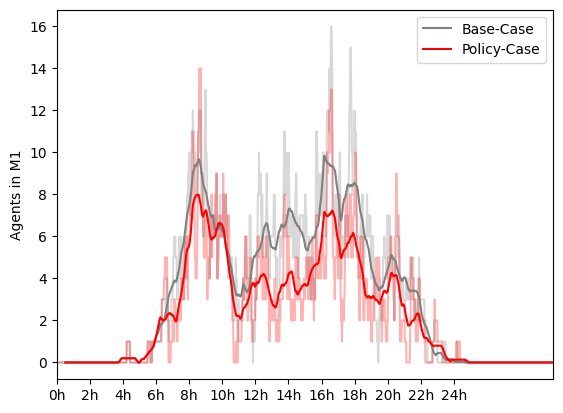

In [25]:


def utilPNG(line, color):
    data_base = pd.read_csv("pt_util_base_"+line+".csv")
    data_policy = pd.read_csv("pt_util_policy_"+line+".csv")
    data_base = data_base.rename(columns={"Util_"+line: "Util_line_base"})
    data_policy = data_policy.rename(columns={"Util_"+line: "Util_line_policy"})
    data_base = data_base.rename(columns={"Util_PT": "Util_PT_base"})
    data_policy = data_policy.rename(columns={"Util_PT": "Util_PT_policy"})
    
    
    data = pd.merge(data_base, data_policy, on="Minute")
    
    
    fig, ax = plt.subplots()
    
    ax.plot(data["Minute"],data["Util_line_base"], color="grey",alpha= 0.3)
    ax.plot(data["Minute"],data["Util_line_policy"], color=color,alpha= 0.3)
    ax.plot(data["Util_line_base"].rolling(60,center=True).mean(), color="grey", alpha =1, label= "Base-Case")
    ax.plot(data["Util_line_policy"].rolling(60,center=True).mean(), color=color, alpha =1, label= "Policy-Case")
    
    
    ticks_x = [i*120 for i in range(13)]
    labels_x = [f"{i//60}h" for i in ticks_x]
    ax.set_xlim(0, 30*60)
    #ax.set_ylim(0, 160)

    ax.set_xticks(ticks_x, labels_x)
    ax.set_ylabel("Agents in " + line[:-1])
    ax.legend()
    plt.show()
    fig.savefig(line[:-1] + ".png")

#utilPNG("U9", "#f3791d")
#utilPNG("U2", "#da421e")
#utilPNG("S41", "green")
#utilPNG("S42", "green")
#utilPNG("S25", "darkgreen")
#utilPNG("S85", "darkgreen")
#utilPNG("S2", "darkgreen")
#utilPNG("S26", "darkgreen")
utilPNG("M1-", "red")
#utilPNG("S3", "blue")


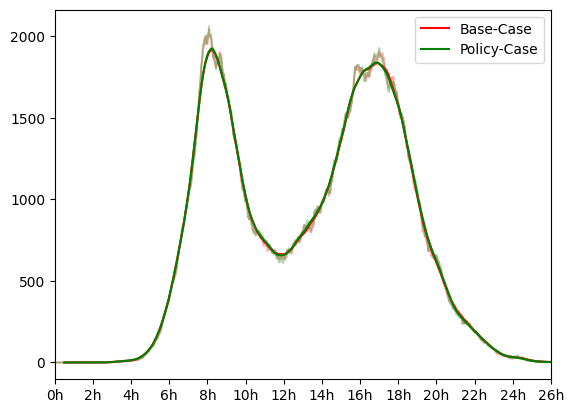

In [12]:
def stuff(line, color):

    data_base = pd.read_csv("pt_util_base_"+line+".csv")
    data_policy = pd.read_csv("pt_util_policy_"+line+".csv")
    data_base = data_base.rename(columns={"Util_"+line: "Util_line_base"})
    data_policy = data_policy.rename(columns={"Util_"+line: "Util_line_policy"})
    data_base = data_base.rename(columns={"Util_PT": "Util_PT_base"})
    data_policy = data_policy.rename(columns={"Util_PT": "Util_PT_policy"})
    
    
    data = pd.merge(data_base, data_policy, on="Minute")
    
    fig, ax = plt.subplots()
    
    ax.plot(data["Minute"],data["Util_PT_base"], color="red",alpha= 0.3)
    ax.plot(data["Minute"],data["Util_PT_policy"], color="green",alpha= 0.3)
    ax.plot(data["Util_PT_base"].rolling(60,center=True).mean(), color="red", alpha =1, label= "Base-Case")
    ax.plot(data["Util_PT_policy"].rolling(60,center=True).mean(), color="green", alpha =1, label= "Policy-Case")
    
    
    ticks_x = [i*120 for i in range(14)]
    labels_x = [f"{i//60}h" for i in ticks_x]
    ax.set_xlim(0, 26*60)
    ax.set_xticks(ticks_x, labels_x)
    ax.legend()
    plt.show()
stuff("U2","red")

In [24]:
line = "U2"

data_persons_base = pd.read_csv("agentList_u2u9policy.csv",names=["ID","a"])
data_persons_policy = pd.read_csv("agentList_u2u9policy.csv",names=["ID","a"])


print(data_persons_base)


data_persons = pd.merge(data_persons_base, data_persons_policy, on="ID")
print(data_persons)
data_persons["time_save"] = data_persons["TravelTime_x"] - data_persons["TravelTime_y"]
fig, ax = plt.subplots()

ax.hist(data_persons["time_save"],15)

plt.show()
print(data_persons_base["TravelTime"].describe())
print(data_persons_policy["TravelTime"].describe())
print(data_persons["time_save"].describe())

                                                  ID                 a
0                                    berlin_00ac7093        home_86400
1                                    berlin_014345b1        home_86400
2                                    berlin_0203eeeb        home_86400
3                                    berlin_024e1179        home_86400
4                                    berlin_0256554d        home_86400
..                                               ...               ...
437          commercialPersonTraffic_re_vkz.1614_4_0  commercial_start
438  commercialPersonTraffic_service_re_vkz.1651_3_9  commercial_start
439                     goodsTraffic_re_vkz.1603_4_3  commercial_start
440                     goodsTraffic_re_vkz.1612_5_1  commercial_start
441                     goodsTraffic_re_vkz.1651_6_3  commercial_start

[442 rows x 2 columns]
                                                  ID               a_x  \
0                                    berlin_00ac70

KeyError: 'TravelTime_x'